# Building legal characteristics on top of aviation network



## PART 1: connecting to memgraph; building aviation/legal search vocabulary 

difference with fien- don't aggregate the edges- retain temporal information and document details for context later

In [52]:
# imports
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import scipy
from IPython.display import Image, display
import seaborn as sns
import re
from pathlib import Path
from collections import Counter
import json

In [2]:
# connection to graph
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("", ""))

In [7]:
# creation of functions for easy Cypher running via VSC

def run_query(cypher, params=None):
    """
    Run a Cypher query and return results as a pandas DataFrame.
    """
    with driver.session() as session:
        result = session.run(cypher, params or {})
        return pd.DataFrame([dict(r) for r in result])


# Verify connection and confirm full import
counts = run_query("""
    MATCH (n)
    RETURN count(n) AS node_count
""")

edge_counts = run_query("""
    MATCH ()-[r]->()
    RETURN count(r) AS edge_count
""")

print("Connected to Memgraph.")
print(f"Nodes : {counts['node_count'][0]:,}  (expected 546,648)")
print(f"Edges : {edge_counts['edge_count'][0]:,}  (expected 1,432,277)")

Connected to Memgraph.
Nodes : 546,648  (expected 546,648)
Edges : 1,432,277  (expected 1,432,277)


In [4]:
# for use of python lists with Cypher
def to_cypher_list(lst):
    return '[' + ', '.join(f'"{item}"' for item in lst) + ']'

In [ ]:
## LISTS DEFIENED FOR ELABORATION AVIATON AND LEGAL NETWORKS

# (1) EPSTEIN NAMES - defining all names for epstein (all nodes we identified that represent Epstein)
EPSTEIN_NAMES = ["Jeffrey Epstein", "Jeff Epstein", "Epstein"]

# (2) LEGAL KEYWORDS
LEGAL_KEYWORDS = [
    # Criminal law
    'pleaded guilty',
    'indicted',
    'convicted',
    'sentenced',
    'arrested',
    'prosecuted',
    'charged',
    'prison sentence',
    'sex offender',
    'accused',
    # Non-prosecution
    'non-prosecution',
    'plea deal',
    'plea bargain',
    # Civil law
    'sued',
    'lawsuit',
    'filed suit',
    'filed complaint',
    'filed civil',
    'filed defamation',
    'filed claim',
    'filed federal',
    'civil action against',
    'defamation claim',
    'defamation action',
    'federal civil suit',
    'settled',
    # Procedural
    'subpoena',
    'deposition',
    'attempted to depose',
    'deposed',
    'filed motion',
    'filed counterclaim',
    'filed bar complaint',
    'filed allegations',
    'filed response',
    'introduce evidence',
    'exclusion of evidence',
    'argued before',
    # Testimonies
    'testimony',
    'testified before',
    'investigated',
    'accused',
    # Fifth Amendment
    'fifth amendment',
    'self-incrimination',
    'took the fifth',
    # Immunity
    'granted immunity',
    'received immunity',
    'agreed not to prosecute',
    # questionned 
    'questioned about allegations',
    'questioned victim about',
    'questioned about lunch meeting',
    'questioned about breakfast meeting',
    'questioned about attending meeting',
    'questioned about requesting legal help'
]

# (3) NON LEGAL ACTIONS - actions caught by LEGAL_KEYWORDS but not actually legal
NON_LEGAL_ACTIONS = [
    'questioned belief about war',
    'questioned happiness of',
    'shared article about Glencore subpoena',
    'questioned interview coverage and mentioned Deutsche Bank papers',
    'shared legal news about lawsuit against',
    'questioned claim about',
    'questioned stance of',
    'questioned admissions by',
    'questioned motive of',
    'questioned need for face‑to‑face discussion with',
    'questioned why note is bad form',
    'questioned communication method',
    'questioned exit note',
    'issued',
    'initiated conversation with and questioned',
    'forwarded media inquiry and lawsuit to',
    'forwarded lawsuit email to'
]

# (4) AVIATION ACTIONS
AVIATION_ACTIONS = [
    # Core travel with person
    'traveled with',
    'traveled_with',
    'travelled with',
    'accompanied',
    'accompanied by',
    'traveled to Little St James with',
    'traveled with to multiple residences',
    'traveled with on private plane',
    'traveled to Caribbean location with',
    'traveled to Europe with',
    'traveled extensively with',
    'traveled internationally with',
    'traveled internationally on private jet with',
    'traveled by private jet with',
    'traveled on private jet with',
    'traveled on private jet of',
    'traveled on private airplane with',
    'traveled on private plane with',
    'traveled on aircraft with',
    'traveled on jet owned by',
    'traveled on jet of',
    'traveled on flight with',
    'traveled on plane with',
    'traveled on planes in interstate commerce related to',
    'traveled aboard planes and boats of',
    'traveled via private jet of',
    'traveled via private aircraft with',
    'traveled on private aircraft owned by',
    'traveled on aircraft owned by',
    'traveled by helicopter provided by',
    # Flew variants
    'flew',
    'flew with',
    'flew_with',
    'flew on',
    'flew to',
    'flew on jet of',
    'flew on private jet of',
    'flew on private jet owned by',
    'flew on private jet to Africa',
    'flew on private jet',
    'flew on private plane of',
    'flew on airplane of',
    'flew on plane of',
    'flew on plane owned by',
    'flew on plane',
    'flew as passenger on',
    'flew to Africa',
    'flew to Africa with',
    'flew to South Africa with',
    'flew to and represented',
    'flew internationally with',
    'flew internationally to meet',
    'flew two young women to dinner to entertain',
    'flew with as passenger on aircraft owned by',
    'flew Gulfstream to',
    'flew with pilot',
    'allegedly flew',
    'allegedly flew victim to',
    'allegedly flew victims to',
    'allegedly flew to London',
    'allegedly flew for entertainment purposes to',
    # Transported variants
    'transported via private jet',
    'transported on private jet with',
    'transported via private aircraft as',
    'transported to Africa',
    'transported and sexually abused',
    'transported victim via',
    'transported victims via',
    'transported young girls via private aircraft with',
    'transported underage females across state lines using',
    'transported to various properties',
    'transported with',
    'transported to',
    'was transported via private jet by',
    'was transported to residence of',
    'allegedly transported for sexual purposes to',
    'allegedly transported and coerced',
    'allegedly transported victim with',
    'allegedly transported minors on',
    # Aircraft/jet specific
    'entertained on private jet',
    'hosted on private aircraft',
    'provided private jet travel to',
    'provided flights on jets to',
    'provided private jet to',
    'provided private jet for transport of',
    'provided private jet service to',
    'provided transportation via private jet to',
    'provided air transport to',
    'provided aircraft for travel with',
    'provided aircraft to',
    'offered transportation via private jet to',
    'offered jet ride to',
    'offered jet ride',
    'offered jet transport to',
    'offered jet charter to',
    'offered ride to Europe on jet',
    'invited to fly on private jet',
    'flew with as passenger on aircraft owned by',
    'boarded aircraft with',
    'arrived at private aircraft with',
    'ceased flying on aircraft with',
    'chartered private plane to transport guests to',
    'chartered private aircraft for',
    'used jet provided by',
    'used aircraft to transport to Africa',
    'operated Boeing aircraft with',
    'operated private airplane transporting',
    'began international travel with',
    'began traveling with',
    'traveled with Jeffrey Epstein',
    'hosted private jet flight for',
    'stepped away from royal jet and offered BBJ opportunity',
    # Flight log references
    'appears on flight logs with',
    'appeared in flight logs of',
    'appeared_in_flight_logs_of',
    'appeared on flight log with',
    'appeared on flight logs of',
    # Allegedly traveled
    'allegedly traveled with victim to',
    'allegedly arranged helicopter travel for',
    'allegedly instructed to travel and engage in sexual activity with',
    # Recruited and transported
    'recruited and transported to',
    'recruited and transported minors for',
    'recruited and transported girls to',
    'recruited and transported girls for',
    'recruited and transported underage girls for',
    'coordinated recruitment and transport to',
    # added after a second time feeding all actions to claude to verify answer
    'traveled with and attended to',
    'traveled internationally with and exploited for sex acts',
    'traveled to and exploited victims at',
    'traveled to and resided in',
    'traveled to during house arrest on',
    'traveled regularly with',
    'flew on private aircraft owned by',
    'transported on aircraft','hosted and transported to',
    'accepted air travel from',
    'accepted air transportation from',
    'directed to travel to and provide sexual services at',
    'directed to travel to island',
]

# (5) NOISE TERMS
NOISE_TERMS = [
    'jet', 'plane', 'aircraft', 'helicopter', 'island', 'ranch', 'apartment',
    'conference', 'driver', 'therapist',
    'real estate', 'property', 'NU', "victims' rights",'London',
    'multiple properties',
    'sexual assaults',
    'dinner event',
    'modeling agency',
]

## Building Aviation Network (Fien's work)

In [13]:
# Building of Aviation network 
## step 1 - raw aviation network
df_aviation = run_query(f"""
MATCH (epstein:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE epstein.name IN {to_cypher_list(EPSTEIN_NAMES)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}
WITH other, r, id(r) AS edge_id
WITH other,
     count(DISTINCT edge_id) AS connection_count,
     collect(DISTINCT r.action)[0..5] AS actions_used
RETURN other.name AS entity,
       other.entity_type AS entity_type,
       connection_count,
       actions_used
ORDER BY connection_count DESC
""")
print(f"Total entities: {len(df_aviation)}")
# print(df_aviation.to_string())

Total entities: 92


In [61]:
## step 2 - aviation network: removal of noise entities from aviation network
def is_noise_entity(name):
    if name is None:
        return True
    name_lower = name.lower()
    return any(term.lower() in name_lower for term in NOISE_TERMS)

aviation_clean = df_aviation[
    ~df_aviation['entity'].apply(is_noise_entity)
].reset_index(drop=True)

print(f"Before noise filter: {len(df_aviation)}")
print(f"After noise filter: {len(aviation_clean)}")
# print(aviation_clean.to_string())

Before noise filter: 92
After noise filter: 69


In [62]:
## step 3 - aviation network: consolidation of double entities in aviation network
ENTITY_CONSOLIDATION = {
    # Bill Clinton
    'President Clinton': 'Bill Clinton',
    # Alan Dershowitz
    'Professor Dershowitz': 'Alan M. Dershowitz',
    'Alan Dershowitz and Tatiana': 'Alan M. Dershowitz',
    # Lawrence Summers
    'Lawrence Henry Summers': 'Lawrence Summers',
    # Andrés Pastrana
    'Andrés Pastrana': 'Andrés Pastrana Arango',
    # Virginia Giuffre
    'Virginia L. Giuffre': 'Virginia Roberts Giuffre',
    'Virginia': 'Virginia Roberts Giuffre',
    # Thorbjørn Jagland
    'Thorbjorn Jagland': 'Thorbjørn Jagland',
    # Jean-Luc Brunel
    'Jean Luc Brunel': 'Jean-Luc Didier Henri-Rene Brunel',
}

def consolidate_entity(name):
    return ENTITY_CONSOLIDATION.get(name, name)

aviation_clean['entity_consolidated'] = aviation_clean['entity'].apply(consolidate_entity)

# aggregation per consolidated entity
aviation_consolidated = aviation_clean.groupby('entity_consolidated').agg(
    connection_count=('connection_count', 'sum'),
    entity_type=('entity_type', 'first'),
).reset_index().rename(columns={'entity_consolidated': 'entity'})

aviation_consolidated = aviation_consolidated.sort_values('connection_count', ascending=False).reset_index(drop=True)

print(f"Before consolidation: {len(aviation_clean)}")
print(f"After consolidation: {len(aviation_consolidated)}")
# print(aviation_consolidated.to_string())

Before consolidation: 69
After consolidation: 60



## Event-level aviation network

The static aviation graph above aggregates entities early. Here we keep one row per aviation-related relationship, retaining timestamp and document provenance before later aggregation.

In [ ]:

df_aviation_events = run_query(f"""
MATCH (epstein:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE epstein.name IN {to_cypher_list(EPSTEIN_NAMES)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}

OPTIONAL MATCH (d:Document {{doc_id: r.doc_id}})

RETURN
    epstein.name AS epstein_name,
    other.name AS entity,
    other.entity_type AS entity_type,
    r.action AS action,
    r.timestamp AS timestamp,
    r.doc_id AS doc_id,
    r.claim_id AS claim_id,
    r.sequence_order AS sequence_order,
    d.category AS document_category,
    d.file_path AS file_path,
    d.paragraph_summary AS paragraph_summary
ORDER BY timestamp, entity
""")

print(f"Raw event-level aviation edges: {len(df_aviation_events):,}")

# Remove noise entities
df_aviation_events = (
    df_aviation_events[
        ~df_aviation_events["entity"].apply(is_noise_entity)
    ]
    .reset_index(drop=True)
)

print(f"After noise filter: {len(df_aviation_events):,}")

# Consolidate duplicate / alternative entity names
df_aviation_events["entity_original"] = df_aviation_events["entity"]
df_aviation_events["entity"] = df_aviation_events["entity"].apply(consolidate_entity)

print(
    "Unique entities before consolidation:",
    df_aviation_events["entity_original"].nunique()
)

print(
    "Unique entities after consolidation:",
    df_aviation_events["entity"].nunique()
)

Raw event-level aviation edges: 290
After noise filter: 264
Unique entities before consolidation: 69
Unique entities after consolidation: 60
Saved: aviation_events_provenance.csv
Rows: 264
Columns: 12


### manually review nodes to prune and select actors

In [98]:
aviation_entity_review = (
    df_aviation_events
    .groupby("entity")
    .agg(
        aviation_claims=("claim_id", "nunique"),
        aviation_docs=("doc_id", "nunique"),
        actions=("action", lambda x: sorted(set(x))[:10]),
        document_groups=("document_group", lambda x: sorted(set(x)))
    )
    .reset_index()
    .sort_values("aviation_docs", ascending=False)
)

aviation_entity_review.head()

,entity,aviation_claims,aviation_docs,actions,document_groups
4,Bill Clinton,100,88,"[accepted air travel from, accompanied, allege...","[communication, legal, media, mixed]"
34,Virginia Roberts Giuffre,19,15,[allegedly instructed to travel and engage in ...,"[communication, legal, media, mixed]"
12,Ghislaine Maxwell,14,14,"[accompanied, accompanied by, allegedly transp...","[communication, legal, media, mixed]"
22,Kevin Spacey,14,14,"[flew, flew to Africa, flew to South Africa wi...","[legal, media]"
2,Alan M. Dershowitz,14,11,"[appeared on flight log with, appeared_in_flig...","[communication, legal, media]"


In [89]:
# Curated core aviation actor set

AVIATION_CORE_ACTORS = [

    "Adriana Mucinska",
    "Al Gore",
    "Alan M. Dershowitz",
    "Andrés Pastrana Arango",
    "Bill Clinton",
    "Bill Richardson",
    "Casey Wasserman",
    "Chris Tucker",
    "Donald Trump",
    "Ehud Barak",
    "Ghislaine Maxwell",
    "Haley Robson",
    "Heidi Klum",
    "Hoffenberg",
    "Jean-Luc Didier Henri-Rene Brunel",
    "Kevin Spacey",
    "Larry Visoski",
    "Lawrence Summers",
    "Matt Groning",
    "Nadia Marcinkova",
    "Naomi Campbell",
    "Prince Andrew, Duke of York",
    "Ron Burkle",
    "Sandy Berger",
    "Sarah Kellen",
    "Thorbjørn Jagland",
    "Virginia Roberts Giuffre"
]

print(f"Curated aviation actors: {len(AVIATION_CORE_ACTORS)}")
print(sorted(AVIATION_CORE_ACTORS))

Curated aviation actors: 27
['Adriana Mucinska', 'Al Gore', 'Alan M. Dershowitz', 'Andrés Pastrana Arango', 'Bill Clinton', 'Bill Richardson', 'Casey Wasserman', 'Chris Tucker', 'Donald Trump', 'Ehud Barak', 'Ghislaine Maxwell', 'Haley Robson', 'Heidi Klum', 'Hoffenberg', 'Jean-Luc Didier Henri-Rene Brunel', 'Kevin Spacey', 'Larry Visoski', 'Lawrence Summers', 'Matt Groning', 'Nadia Marcinkova', 'Naomi Campbell', 'Prince Andrew, Duke of York', 'Ron Burkle', 'Sandy Berger', 'Sarah Kellen', 'Thorbjørn Jagland', 'Virginia Roberts Giuffre']


In [90]:
# Curated aviation actor dataframe

df_aviation_curated = (
    df_aviation_events[
        df_aviation_events["entity"].isin(AVIATION_CORE_ACTORS)
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Rows: {len(df_aviation_curated):,}")
print(f"Unique actors: {df_aviation_curated['entity'].nunique()}")

print("\nActors retained:")
print(sorted(df_aviation_curated["entity"].unique()))

Rows: 220
Unique actors: 27

Actors retained:
['Adriana Mucinska', 'Al Gore', 'Alan M. Dershowitz', 'Andrés Pastrana Arango', 'Bill Clinton', 'Bill Richardson', 'Casey Wasserman', 'Chris Tucker', 'Donald Trump', 'Ehud Barak', 'Ghislaine Maxwell', 'Haley Robson', 'Heidi Klum', 'Hoffenberg', 'Jean-Luc Didier Henri-Rene Brunel', 'Kevin Spacey', 'Larry Visoski', 'Lawrence Summers', 'Matt Groning', 'Nadia Marcinkova', 'Naomi Campbell', 'Prince Andrew, Duke of York', 'Ron Burkle', 'Sandy Berger', 'Sarah Kellen', 'Thorbjørn Jagland', 'Virginia Roberts Giuffre']


### find all relationships between main actors

In [114]:
# Full aviation network search:
# Epstein aliases + curated aviation actor aliases
# This captures both:
# 1. Epstein ↔ curated actors
# 2. curated actor ↔ curated actor

aviation_core_original_names = (
    df_aviation_curated["entity_original"]
    .dropna()
    .unique()
    .tolist()
)

full_aviation_query_names = sorted(
    set(aviation_core_original_names + EPSTEIN_NAMES)
)

print(f"Original curated actor names: {len(aviation_core_original_names)}")
print(f"Full aviation query names incl. Epstein aliases: {len(full_aviation_query_names)}")


df_aviation_full_events = run_query(f"""
MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)

WHERE a.name IN {to_cypher_list(full_aviation_query_names)}
AND b.name IN {to_cypher_list(full_aviation_query_names)}

OPTIONAL MATCH (d:Document {{doc_id: r.doc_id}})

RETURN
    a.name AS source,
    b.name AS target,
    r.action AS action,
    r.timestamp AS timestamp,
    r.doc_id AS doc_id,
    r.claim_id AS claim_id,
    r.sequence_order AS sequence_order,
    d.category AS document_category,
    d.file_path AS file_path,
    d.paragraph_summary AS paragraph_summary

ORDER BY source, target, timestamp
""")

print(f"Raw full aviation event rows: {len(df_aviation_full_events):,}")

df_aviation_full_events.head()

Original curated actor names: 36
Full aviation query names incl. Epstein aliases: 39
Raw full aviation event rows: 8,558


,source,target,action,timestamp,doc_id,claim_id,sequence_order,document_category,file_path,paragraph_summary
0,Adriana Mucinska,Alan M. Dershowitz,traveled on flight #1843 with,2005-11-17,HOUSE_OVERSIGHT_016200,HOUSE_OVERSIGHT_016200:7,7,court_filing,data/new_docs_nov2024_processed/tranche_012/HO...,This document is a court filing (Case 1:19‑cv‑...
1,Adriana Mucinska,Alan M. Dershowitz,invoked Fifth Amendment when asked about,None,HOUSE_OVERSIGHT_021824_part1,HOUSE_OVERSIGHT_021824_part1:8,8,transcript,data/001_split/HOUSE_OVERSIGHT_021824_part1.txt,This is a videotaped deposition transcript fro...
2,Adriana Mucinska,Bill Clinton,traveled with,None,HOUSE_OVERSIGHT_010593,HOUSE_OVERSIGHT_010593:3,3,report,data/new_docs_nov2024_processed/tranche_006/HO...,The document is a fragment of a House Oversigh...
3,Adriana Mucinska,Bill Clinton,flew with,None,HOUSE_OVERSIGHT_011946,HOUSE_OVERSIGHT_011946:13,13,court_filing,data/new_docs_nov2024_processed/tranche_007/HO...,The document is a collection of court‑filing e...
4,Adriana Mucinska,Bill Clinton,flew with,None,HOUSE_OVERSIGHT_013346,HOUSE_OVERSIGHT_013346:3,3,court_filing,data/new_docs_nov2024_processed/tranche_001/HO...,This excerpt from a legal filing discusses evi...


In [115]:
# Consolidate duplicate / alternative entity names in full aviation network

df_aviation_full_events["source_original"] = df_aviation_full_events["source"]
df_aviation_full_events["target_original"] = df_aviation_full_events["target"]

df_aviation_full_events["source"] = (
    df_aviation_full_events["source"]
    .apply(consolidate_entity)
)

df_aviation_full_events["target"] = (
    df_aviation_full_events["target"]
    .apply(consolidate_entity)
)

# Normalize Epstein aliases
epstein_aliases = {
    "Jeff Epstein": "Jeffrey Epstein",
    "Epstein": "Jeffrey Epstein"
}

df_aviation_full_events["source"] = df_aviation_full_events["source"].replace(epstein_aliases)
df_aviation_full_events["target"] = df_aviation_full_events["target"].replace(epstein_aliases)

print("Unique source nodes after consolidation:", df_aviation_full_events["source"].nunique())
print("Unique target nodes after consolidation:", df_aviation_full_events["target"].nunique())

Unique source nodes after consolidation: 28
Unique target nodes after consolidation: 28


In [116]:
# Canonicalize node pairs so A--B and B--A are treated as the same edge

df_aviation_full_events["node_1"] = (
    df_aviation_full_events[["source", "target"]].min(axis=1)
)

df_aviation_full_events["node_2"] = (
    df_aviation_full_events[["source", "target"]].max(axis=1)
)

# Remove exact document-level duplicates for the same unordered pair and reduce to unique documents
df_aviation_full_events = (
    df_aviation_full_events
    .drop_duplicates(subset=["node_1", "node_2", "doc_id"])
    .reset_index(drop=True)
)

print(f"Rows after canonical pair deduplication: {len(df_aviation_full_events):,}")

# Save event-level aviation table

df_aviation_full_events.to_csv(
    "aviation_full_events_provenance.csv",
    index=False
)

print("Saved: aviation_full_events_provenance.csv")
print(f"Rows: {len(df_aviation_full_events):,}")
print(f"Columns: {len(df_aviation_full_events.columns)}")

Rows after canonical pair deduplication: 2,853
Saved: aviation_full_events_provenance.csv
Rows: 2,853
Columns: 14


## Build Exploratory Network Graph


### Full Aviation Network

In [133]:
## review of document categories in aviation events
DOC_CATEGORY_MAP = {

    # LEGAL / OFFICIAL
    "court_filing": "legal",
    "legal_filing": "legal",
    "transcript": "legal",
    "public_record": "legal",
    "public_records": "legal",

    # MEDIA / SECONDARY SOURCES
    "media_article": "media",
    "report": "media",
    "book_excerpt": "media",

    # DIRECT COMMUNICATION
    "email": "communication",
    "letter": "communication",
    "memorandum": "communication",

    # FINANCIAL / BUSINESS
    "financial_document": "financial",

    # MIXED / UNCERTAIN
    "mixed_document": "mixed",
    "other": "other"
}

def map_document_group(category):
    if pd.isna(category):
        return "unknown"
    
    category = str(category).strip()
    
    return DOC_CATEGORY_MAP.get(category, "other")


# Apply to aviation events
df_aviation_full_events["document_group"] = (
    df_aviation_full_events["document_category"]
    .apply(map_document_group)
)

print("AVIATION DOCUMENT GROUPS")
print(df_aviation_full_events["document_group"].value_counts(dropna=False))

AVIATION DOCUMENT GROUPS
document_group
communication    1227
media             827
legal             574
mixed             191
financial          19
other              14
unknown             1
Name: count, dtype: int64


In [146]:
# Aggregate aviation graph to document-supported edge table

from collections import Counter

# Aggregate aviation graph to provenance-aware edge table

edge_records = []

for (n1, n2), group in df_aviation_full_events.groupby(["node_1", "node_2"]):

    # document-deduplicated group counts
    doc_groups = (
        group[["doc_id", "document_group"]]
        .drop_duplicates()
    )

    group_counter = Counter(doc_groups["document_group"])

    total_docs = sum(group_counter.values())

    dominant_group = (
        group_counter.most_common(1)[0][0]
        if total_docs > 0 else "unknown"
    )

    edge_records.append({

        "source": n1,
        "target": n2,

        # edge strength
        "weight": group["doc_id"].nunique(),
        "claim_count": group["claim_id"].nunique(),

        # provenance composition
        "legal_docs": group_counter.get("legal", 0),
        "media_docs": group_counter.get("media", 0),
        "communication_docs": group_counter.get("communication", 0),
        "financial_docs": group_counter.get("financial", 0),
        "mixed_docs": group_counter.get("mixed", 0),
        "other_docs": group_counter.get("other", 0),

        "total_docs": total_docs,

        "legal_prop": group_counter.get("legal", 0) / total_docs if total_docs else 0,

        "dominant_document_group": dominant_group,

        # optional interpretability
        "actions": sorted(set(group["action"].dropna()))[:10]
    })

df_aviation_edges = pd.DataFrame(edge_records)

print(f"Aggregated aviation edges: {len(df_aviation_edges):,}")

df_aviation_edges.head()

Aggregated aviation edges: 68


,source,target,weight,claim_count,legal_docs,media_docs,communication_docs,financial_docs,mixed_docs,other_docs,total_docs,legal_prop,dominant_document_group,actions
0,Adriana Mucinska,Alan M. Dershowitz,2,2,2,0,0,0,0,0,2,1.000000,legal,"[invoked Fifth Amendment when asked about, tra..."
1,Adriana Mucinska,Bill Clinton,3,3,2,1,0,0,0,0,3,0.666667,legal,"[flew with, traveled with]"
2,Adriana Mucinska,Jeffrey Epstein,1,1,0,1,0,0,0,0,1,0.000000,media,[traveled with]
3,Al Gore,Ghislaine Maxwell,3,3,1,2,0,0,0,0,3,0.333333,media,"[refuted_claim_about, was characterized as fri..."
4,Al Gore,Jeffrey Epstein,18,18,1,5,11,0,1,0,18,0.055556,communication,"[alleged to have no relationship with, claimed..."


In [148]:
# Build aviation NetworkX graph

G_aviation = nx.Graph()

for _, row in df_aviation_edges.iterrows():

    G_aviation.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"]),
        claim_count=int(row["claim_count"]),
        dominant_document_group=";".join(row["dominant_document_group"]),
        actions=";".join(row["actions"])
    )

print(f"Nodes: {G_aviation.number_of_nodes():,}")
print(f"Edges: {G_aviation.number_of_edges():,}")

Nodes: 28
Edges: 68


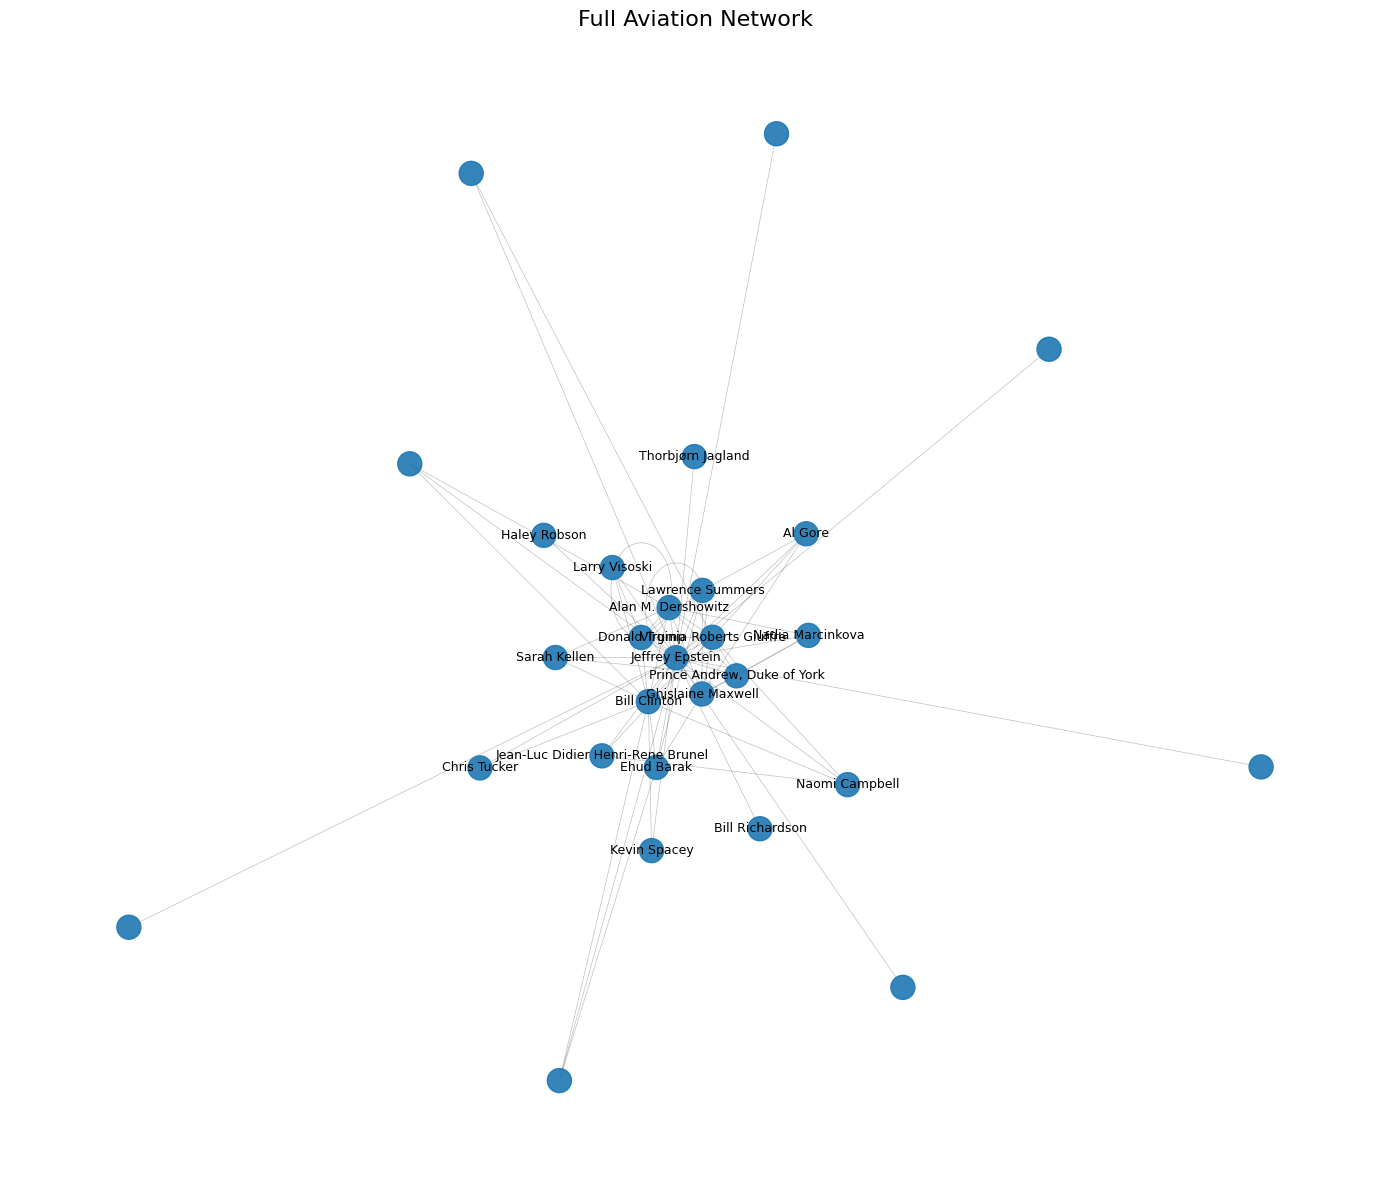

In [149]:
# Basic aviation network visualization

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G_aviation,
    seed=42,
    k=0.7
)

# Node sizes based on weighted degree
weighted_degree = dict(G_aviation.degree(weight="weight"))

node_sizes = [
    300 #+ 120 * weighted_degree[n]
    for n in G_aviation.nodes()
]

# Edge widths based on document-supported weight
edge_widths = [
    0.5 #+ 0.5 * G_aviation[u][v]["weight"]
    for u, v in G_aviation.edges()
]

nx.draw_networkx_edges(
    G_aviation,
    pos,
    width=edge_widths,
    alpha=0.25
)

nx.draw_networkx_nodes(
    G_aviation,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

# Label strongest nodes only
top_nodes = sorted(
    weighted_degree,
    key=weighted_degree.get,
    reverse=True
)[:20]

labels = {n: n for n in top_nodes}

nx.draw_networkx_labels(
    G_aviation,
    pos,
    labels=labels,
    font_size=9
)

plt.title(
    "Full Aviation Network",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()
plt.show()

### Aviation network excluding Epstein

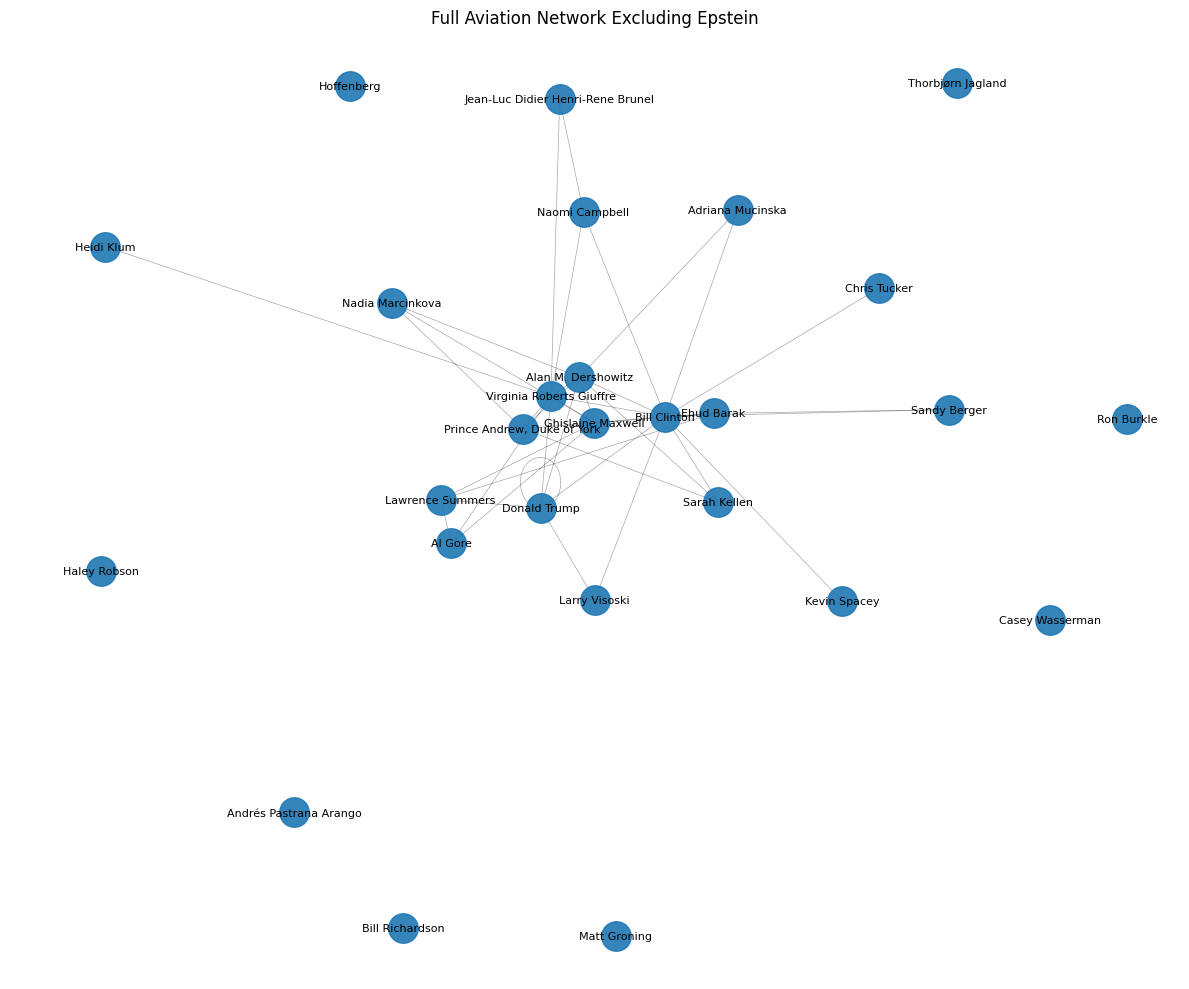

In [150]:
# Aviation network excluding Epstein for structure

G_aviation_no_epstein = G_aviation.copy()
G_aviation_no_epstein.remove_node("Jeffrey Epstein")

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G_aviation_no_epstein,
    seed=42,
    k=1.0
)

nx.draw_networkx_edges(
    G_aviation_no_epstein,
    pos,
    width=[
        0.5 #+ 0.6 * G_aviation_no_epstein[u][v]["weight"]
        for u, v in G_aviation_no_epstein.edges()
    ],
    alpha=0.35
)

nx.draw_networkx_nodes(
    G_aviation_no_epstein,
    pos,
    node_size=450,
    alpha=0.9
)

nx.draw_networkx_labels(
    G_aviation_no_epstein,
    pos,
    font_size=8
)

plt.title("Full Aviation Network Excluding Epstein")
plt.axis("off")
plt.tight_layout()
plt.show()

### Network build from legal documents only

In [139]:
# Legal-document subgraph among curated actors, excluding Epstein

df_legal_subgraph_events = (
    df_aviation_full_events
    .loc[df_aviation_full_events["document_group"] == "legal"]
    .copy()
)

# Remove Epstein edges
df_legal_subgraph_events = (
    df_legal_subgraph_events[
        (df_legal_subgraph_events["source"] != "Jeffrey Epstein") &
        (df_legal_subgraph_events["target"] != "Jeffrey Epstein")
    ]
    .reset_index(drop=True)
)

print(f"Legal event rows excluding Epstein: {len(df_legal_subgraph_events):,}")

Legal event rows excluding Epstein: 213


In [140]:
df_legal_subgraph_edges = (
    df_legal_subgraph_events
    .dropna(subset=["doc_id"])
    .drop_duplicates(subset=["node_1", "node_2", "doc_id"])
    .groupby(["node_1", "node_2"])
    .agg(
        weight=("doc_id", "nunique"),
        claim_count=("claim_id", "nunique"),
        actions=("action", lambda x: sorted(set(x.dropna()))[:10]),
        sample_doc_ids=("doc_id", lambda x: list(pd.Series(x).dropna().unique())[:5])
    )
    .reset_index()
    .rename(columns={"node_1": "source", "node_2": "target"})
)

print(f"Legal document-supported edges: {len(df_legal_subgraph_edges):,}")
df_legal_subgraph_edges.sort_values("weight", ascending=False).head(20)

Legal document-supported edges: 26


,source,target,weight,claim_count,actions,sample_doc_ids
10,Alan M. Dershowitz,Virginia Roberts Giuffre,59,59,"[accused, agreed to waive statute of limitatio...","[HOUSE_OVERSIGHT_015632, TEXT-001-HOUSE_OVERSI..."
21,Ghislaine Maxwell,Virginia Roberts Giuffre,45,45,"[accompanied and prepared, accuses of defamati...","[HOUSE_OVERSIGHT_021705, HOUSE_OVERSIGHT_01483..."
25,"Prince Andrew, Duke of York",Virginia Roberts Giuffre,26,26,"[accused, alleged sexual contact with, alleged...","[HOUSE_OVERSIGHT_014665, HOUSE_OVERSIGHT_01088..."
18,Bill Clinton,Virginia Roberts Giuffre,12,12,"[alleged meeting with, allegedly received offe...","[HOUSE_OVERSIGHT_014670, TEXT-001-HOUSE_OVERSI..."
12,Bill Clinton,Ehud Barak,10,10,"[asked, commented on, discussed, informed, met...","[HOUSE_OVERSIGHT_011836, HOUSE_OVERSIGHT_01183..."
6,Alan M. Dershowitz,Ghislaine Maxwell,9,9,[argued plaintiff made false allegations regar...,"[HOUSE_OVERSIGHT_016200, HOUSE_OVERSIGHT_01075..."
13,Bill Clinton,Ghislaine Maxwell,9,9,[challenged admissibility of allegations regar...,"[HOUSE_OVERSIGHT_011350, HOUSE_OVERSIGHT_01135..."
20,Ghislaine Maxwell,"Prince Andrew, Duke of York",5,5,"[hosted cocktail party, introduced, introduced...","[HOUSE_OVERSIGHT_014829, HOUSE_OVERSIGHT_03059..."
7,Alan M. Dershowitz,Nadia Marcinkova,4,4,"[had sexual intercourse with, invoked Fifth Am...","[HOUSE_OVERSIGHT_018036, HOUSE_OVERSIGHT_01075..."
9,Alan M. Dershowitz,Sarah Kellen,4,4,"[invoked Fifth Amendment when asked about, too...","[HOUSE_OVERSIGHT_016200, HOUSE_OVERSIGHT_01075..."


In [141]:
G_legal = nx.Graph()

for _, row in df_legal_subgraph_edges.iterrows():
    G_legal.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"]),
        claim_count=int(row["claim_count"]),
        actions=";".join(row["actions"]),
        sample_doc_ids=";".join(row["sample_doc_ids"])
    )

print(f"Legal graph nodes: {G_legal.number_of_nodes():,}")
print(f"Legal graph edges: {G_legal.number_of_edges():,}")

Legal graph nodes: 17
Legal graph edges: 26


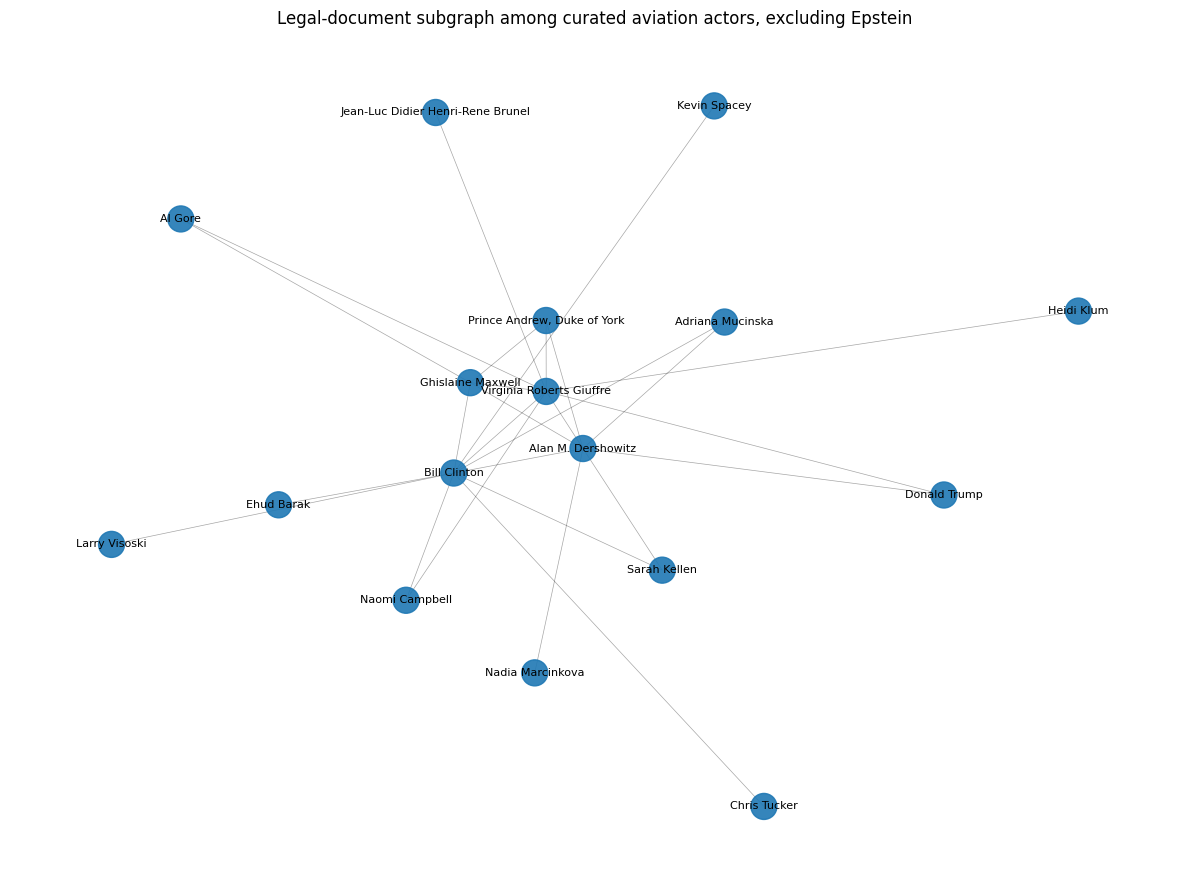

In [142]:
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G_legal, seed=42, k=1.0)

edge_widths = [
    0.5 #+ 0.7 * G_legal[u][v]["weight"]
    for u, v in G_legal.edges()
]

weighted_degree = dict(G_legal.degree(weight="weight"))

node_sizes = [
    350 #+ 100 * weighted_degree[n]
    for n in G_legal.nodes()
]

nx.draw_networkx_edges(
    G_legal,
    pos,
    width=edge_widths,
    alpha=0.35
)

nx.draw_networkx_nodes(
    G_legal,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_labels(
    G_legal,
    pos,
    font_size=8
)

plt.title("Legal-document subgraph among curated aviation actors, excluding Epstein")
plt.axis("off")
plt.tight_layout()
plt.show()

### centrality measures

In [151]:
# ============================================================
# FULL NETWORK (excluding Epstein)
# ============================================================

G_full_analysis = G_aviation.copy()

if "Jeffrey Epstein" in G_full_analysis.nodes:
    G_full_analysis.remove_node("Jeffrey Epstein")

print("FULL NETWORK (excluding Epstein)")
print(f"Nodes: {G_full_analysis.number_of_nodes():,}")
print(f"Edges: {G_full_analysis.number_of_edges():,}")


# Centrality metrics

degree_full = dict(G_full_analysis.degree(weight="weight"))

betweenness_full = nx.betweenness_centrality(
    G_full_analysis,
    weight="weight"
)

pagerank_full = nx.pagerank(
    G_full_analysis,
    weight="weight"
)

eigenvector_full = nx.eigenvector_centrality(
    G_full_analysis,
    weight="weight",
    max_iter=1000
)


# Build dataframe

df_metrics_full = pd.DataFrame({
    "entity": list(G_full_analysis.nodes()),
    "degree_full": [degree_full[n] for n in G_full_analysis.nodes()],
    "betweenness_full": [betweenness_full[n] for n in G_full_analysis.nodes()],
    "pagerank_full": [pagerank_full[n] for n in G_full_analysis.nodes()],
    "eigenvector_full": [eigenvector_full[n] for n in G_full_analysis.nodes()]
})

df_metrics_full = (
    df_metrics_full
    .sort_values("pagerank_full", ascending=False)
    .reset_index(drop=True)
)

print("\nTop full-network actors:")
print(df_metrics_full.head(15))

FULL NETWORK (excluding Epstein)
Nodes: 27
Edges: 40

Top full-network actors:
                               entity  degree_full  betweenness_full  \
0            Virginia Roberts Giuffre        295.0          0.064615   
1                        Bill Clinton        202.0          0.289231   
2                   Ghislaine Maxwell        213.0          0.067692   
3                  Alan M. Dershowitz        137.0          0.012308   
4                          Ehud Barak        104.0          0.098462   
5         Prince Andrew, Duke of York        107.0          0.018462   
6                        Donald Trump         94.0          0.000000   
7                    Lawrence Summers         25.0          0.106154   
8                       Larry Visoski         18.0          0.000000   
9                      Naomi Campbell          8.0          0.098462   
10                       Sarah Kellen         12.0          0.030769   
11                            Al Gore         12.0       

In [152]:
# ============================================================
# LEGAL-ONLY NETWORK (excluding Epstein)
# ============================================================

print("LEGAL NETWORK")
print(f"Nodes: {G_legal.number_of_nodes():,}")
print(f"Edges: {G_legal.number_of_edges():,}")


# Centrality metrics

degree_legal = dict(G_legal.degree(weight="weight"))

betweenness_legal = nx.betweenness_centrality(
    G_legal,
    weight="weight"
)

pagerank_legal = nx.pagerank(
    G_legal,
    weight="weight"
)

eigenvector_legal = nx.eigenvector_centrality(
    G_legal,
    weight="weight",
    max_iter=1000
)


# Build dataframe

df_metrics_legal = pd.DataFrame({
    "entity": list(G_legal.nodes()),
    "degree_legal": [degree_legal[n] for n in G_legal.nodes()],
    "betweenness_legal": [betweenness_legal[n] for n in G_legal.nodes()],
    "pagerank_legal": [pagerank_legal[n] for n in G_legal.nodes()],
    "eigenvector_legal": [eigenvector_legal[n] for n in G_legal.nodes()]
})

df_metrics_legal = (
    df_metrics_legal
    .sort_values("pagerank_legal", ascending=False)
    .reset_index(drop=True)
)

print("\nTop legal-network actors:")
print(df_metrics_legal.head(15))

LEGAL NETWORK
Nodes: 17
Edges: 26

Top legal-network actors:
                               entity  degree_legal  betweenness_legal  \
0            Virginia Roberts Giuffre         149.0           0.462500   
1                  Alan M. Dershowitz          85.0           0.475000   
2                        Bill Clinton          47.0           0.475000   
3                   Ghislaine Maxwell          69.0           0.004167   
4         Prince Andrew, Duke of York          34.0           0.000000   
5                          Ehud Barak          10.0           0.000000   
6                        Sarah Kellen           7.0           0.000000   
7                      Naomi Campbell           5.0           0.104167   
8                    Adriana Mucinska           4.0           0.000000   
9                       Larry Visoski           3.0           0.000000   
10                   Nadia Marcinkova           4.0           0.000000   
11                       Donald Trump           2.0

In [153]:
# ============================================================
# COMBINED NODE METRICS TABLE
# ============================================================

df_metrics_combined = pd.merge(
    df_metrics_full,
    df_metrics_legal,
    on="entity",
    how="outer"
).fillna(0)

df_metrics_combined = (
    df_metrics_combined
    .sort_values("pagerank_full", ascending=False)
    .reset_index(drop=True)
)

print(df_metrics_combined.head(20))

                               entity  degree_full  betweenness_full  \
0            Virginia Roberts Giuffre        295.0          0.064615   
1                        Bill Clinton        202.0          0.289231   
2                   Ghislaine Maxwell        213.0          0.067692   
3                  Alan M. Dershowitz        137.0          0.012308   
4                          Ehud Barak        104.0          0.098462   
5         Prince Andrew, Duke of York        107.0          0.018462   
6                        Donald Trump         94.0          0.000000   
7                    Lawrence Summers         25.0          0.106154   
8                       Larry Visoski         18.0          0.000000   
9                      Naomi Campbell          8.0          0.098462   
10                       Sarah Kellen         12.0          0.030769   
11                            Al Gore         12.0          0.021538   
12  Jean-Luc Didier Henri-Rene Brunel          4.0          0.00

## Gephi Node/Edge Generation and export

In [159]:
# ============================================================
# Gephi export: edges
# ============================================================

df_gephi_edges = df_aviation_edges.copy()

df_gephi_edges["legal_weight"] = (
    df_gephi_edges["weight"] *
    df_gephi_edges["legal_prop"]
)

df_gephi_edges = df_gephi_edges[[
    "source",
    "target",
    "weight",
    "legal_prop",
    "legal_weight",
    "dominant_document_group"
]].rename(columns={
    "source": "Source",
    "target": "Target",
    "weight": "Weight"
})

df_gephi_edges["Type"] = "Undirected"

df_gephi_edges = (
    df_gephi_edges[
        (df_gephi_edges["Source"] != "Jeffrey Epstein") &
        (df_gephi_edges["Target"] != "Jeffrey Epstein")
    ]
    .copy()
)

df_gephi_edges.to_csv(
    "gephi_edges.csv",
    index=False
)

print(df_gephi_edges.head())

             Source                    Target  Weight  legal_prop  \
0  Adriana Mucinska        Alan M. Dershowitz       2    1.000000   
1  Adriana Mucinska              Bill Clinton       3    0.666667   
3           Al Gore         Ghislaine Maxwell       3    0.333333   
5           Al Gore          Lawrence Summers       1    0.000000   
6           Al Gore  Virginia Roberts Giuffre       8    0.125000   

   legal_weight dominant_document_group        Type  
0           2.0                   legal  Undirected  
1           2.0                   legal  Undirected  
3           1.0                   media  Undirected  
5           0.0           communication  Undirected  
6           1.0                   media  Undirected  


In [160]:
# ============================================================
# Gephi export: nodes
# ============================================================

all_nodes = sorted(
    set(df_gephi_edges["Source"]).union(set(df_gephi_edges["Target"]))
)

df_gephi_nodes = pd.DataFrame({
    "Id": all_nodes,
    "Label": all_nodes
})

# Add full/legal metrics
df_gephi_nodes = df_gephi_nodes.merge(
    df_metrics_combined,
    left_on="Id",
    right_on="entity",
    how="left"
).drop(columns=["entity"], errors="ignore")

df_gephi_nodes = df_gephi_nodes.fillna(0)

df_gephi_nodes.to_csv("gephi_nodes.csv", index=False)

print("Saved: gephi_nodes.csv")
print(df_gephi_nodes.head())

Saved: gephi_nodes.csv
                   Id               Label  degree_full  betweenness_full  \
0    Adriana Mucinska    Adriana Mucinska          5.0          0.030769   
1             Al Gore             Al Gore         12.0          0.021538   
2  Alan M. Dershowitz  Alan M. Dershowitz        137.0          0.012308   
3        Bill Clinton        Bill Clinton        202.0          0.289231   
4        Chris Tucker        Chris Tucker          4.0          0.000000   

   pagerank_full  eigenvector_full  degree_legal  betweenness_legal  \
0       0.010493          0.009460           4.0           0.000000   
1       0.014274          0.034444           2.0           0.116667   
2       0.093394          0.356797          85.0           0.475000   
3       0.151134          0.340557          47.0           0.475000   
4       0.009970          0.007427           1.0           0.000000   

   pagerank_legal  eigenvector_legal  
0        0.017205           0.015643  
1        0.0121